# Machine Learning - Homework 2: Part 1

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

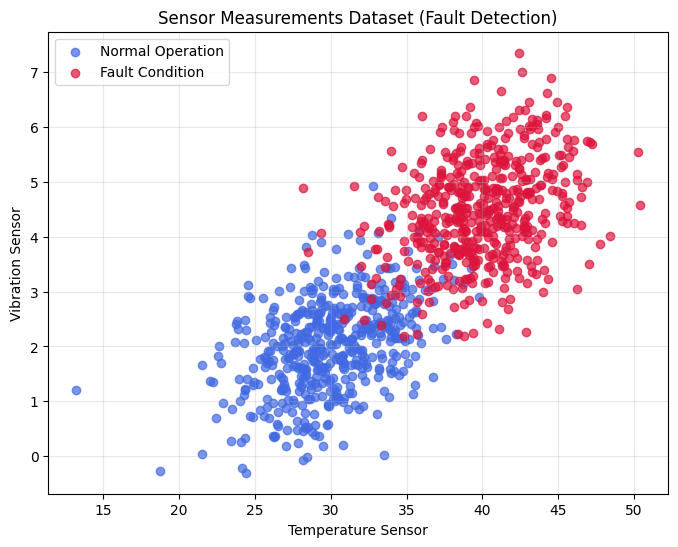

In [140]:
#############################
# DO NOT CHANGE THIS PART
#############################

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)

n_per_class = 500

# Normal machine operation
normal = np.random.multivariate_normal(
    mean=[30, 2],
    cov=[[12, 1.5],
         [1.5, 0.8]],
    size=n_per_class
)

# Fault condition
fault = np.random.multivariate_normal(
    mean=[40, 4.5],
    cov=[[12, 1.0],
         [1.0, 0.8]],
    size=n_per_class
)

X = np.vstack([normal, fault])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

#############################
# DO NOT CHANGE THIS PART
#############################


# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    normal[:,0], normal[:,1],
    color="royalblue",
    label="Normal Operation",
    alpha=0.7
)

plt.scatter(
    fault[:,0], fault[:,1],
    color="crimson",
    label="Fault Condition",
    alpha=0.7
)

plt.xlabel("Temperature Sensor")
plt.ylabel("Vibration Sensor")
plt.title("Sensor Measurements Dataset (Fault Detection)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

[0. 0. 0.]
0.6931471805599454
Iteration 1: loss = 3.784522, w = [0.         0.24817341 0.06149474]
Iteration 2: loss = 17.269388, w = [-0.04995687 -1.25040525 -0.03950707]
Iteration 3: loss = 11.369637, w = [4.31343733e-05 7.45671693e-01 1.84561497e-01]
Iteration 4: loss = 14.877051, w = [-0.04995686 -0.75405836  0.08348242]
Iteration 5: loss = 16.995923, w = [4.31336539e-05 1.24201851e+00 3.07550981e-01]
Iteration 6: loss = 4.706995, w = [-0.04995687 -0.2577116   0.2064719 ]
Iteration 7: loss = 17.256714, w = [-1.01305993e-05  1.73690465e+00  4.30428901e-01]
Iteration 8: loss = 3.865266, w = [-0.05001013  0.23717454  0.32934982]
Iteration 9: loss = 17.269359, w = [-0.09997127 -1.26153618  0.22833059]
Iteration 10: loss = 11.448422, w = [-0.04997127  0.73454076  0.45239915]
Final w0: -0.05
Final w1: 0.7345
Final w2: 0.4524
Final loss J(w^10): 11.4484
Classification error rate: 0.5


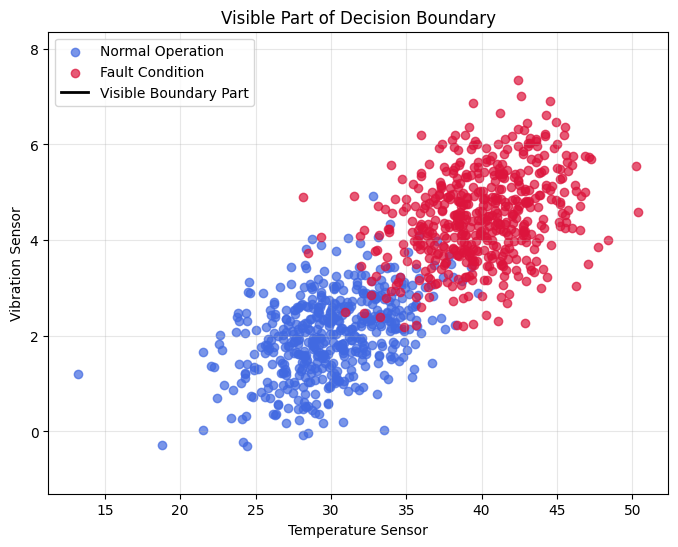

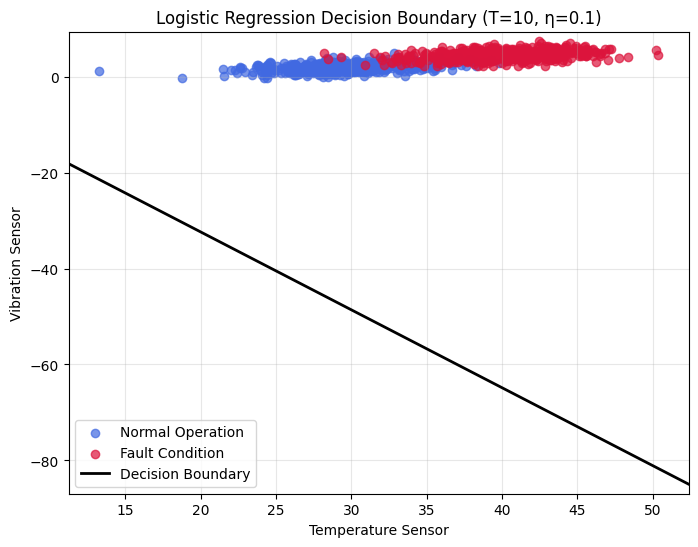

In [141]:

m = X.shape[0]

X_bias = np.hstack((np.ones((m, 1)), X))

#bias, temperature, vibration. starting their weights at 0.
w = np.zeros(3)
print(w)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#matrix multiplication of X_bias and w to get z, then apply sigmoid to get predicted probabilities y_hat.
z = X_bias @ w
y_hat = sigmoid(z)



#compute the loss using the formula in pdf provided
def compute_loss(y, y_hat):
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

#control point as it is given in pdf J(0) = log(2) ≈ 0.6931
initial_loss = compute_loss(y, y_hat)
print(initial_loss)

#gradient descent, 1/m for mean, X.T for transpose, (y_hat - y) for error term.
def compute_gradient(X, y, y_hat):
    m = X.shape[0]
    grad = (1 / m) * (X.T @ (y_hat - y))
    return grad

grad = compute_gradient(X_bias, y, y_hat)


#updating weights using learning rate alpha and gradient. w=w−η∇w​J

learning_rate = 0.1
num_iterations = 10


for i in range(num_iterations):
    z = X_bias @ w
    y_hat = sigmoid(z)
    grad = compute_gradient(X_bias, y, y_hat)
    w -= learning_rate * grad
    loss = compute_loss(y, sigmoid(X_bias @ w))

    print(f"Iteration {i+1}: loss = {loss:.6f}, w = {w}")


z_final = X_bias @ w
y_hat_final = sigmoid(z_final)
final_loss = compute_loss(y, y_hat_final)

y_pred = (y_hat_final >= 0.5).astype(int)
error_rate = np.mean(y_pred != y)


print("Final w0:", round(w[0], 4))
print("Final w1:", round(w[1], 4))
print("Final w2:", round(w[2], 4))
print("Final loss J(w^10):", round(final_loss, 4))
print("Classification error rate:", round(error_rate, 4))


plt.figure(figsize=(8, 6))

plt.scatter(X[y==0, 0], X[y==0, 1], color="royalblue", label="Normal Operation", alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], color="crimson", label="Fault Condition", alpha=0.7)

x1_vals = np.linspace(X[:, 0].min() - 2, X[:, 0].max() + 2, 2000)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]

visible = (x2_vals >= X[:, 1].min() - 1) & (x2_vals <= X[:, 1].max() + 1)
plt.plot(x1_vals[visible], x2_vals[visible], 'k-', linewidth=2, label='Visible Boundary Part')

plt.xlim(X[:, 0].min() - 2, X[:, 0].max() + 2)
plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

plt.xlabel("Temperature Sensor")
plt.ylabel("Vibration Sensor")
plt.title("Visible Part of Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 6))

plt.scatter(X[y==0, 0], X[y==0, 1], color="royalblue", label="Normal Operation", alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], color="crimson", label="Fault Condition", alpha=0.7)

x1_vals = np.linspace(X[:, 0].min() - 2, X[:, 0].max() + 2, 200)
x2_vals = -(w[0] + w[1] * x1_vals) / w[2]

plt.plot(x1_vals, x2_vals, 'k-', linewidth=2, label='Decision Boundary')

plt.xlim(X[:, 0].min() - 2, X[:, 0].max() + 2)
plt.ylim(x2_vals.min() - 2, X[:, 1].max() + 2)

plt.xlabel("Temperature Sensor")
plt.ylabel("Vibration Sensor")
plt.title("Logistic Regression Decision Boundary (T=10, η=0.1)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()





# Machine Learning - Homework 2: Part 2

## 1. Dataset Generation

The dataset that will be used throughout this part is already created and split for you. Do not change any part of the code below.

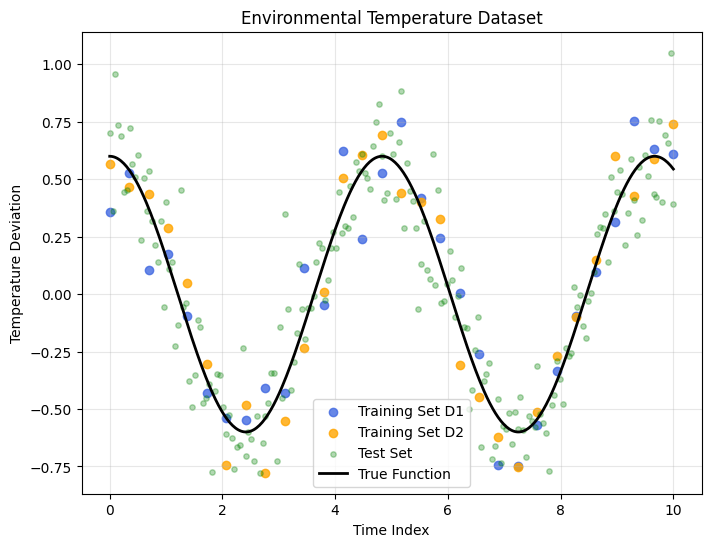

In [142]:
#############################
# DO NOT CHANGE THIS PART
#############################

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)

# Training dataset D1
x_train_d1 = np.linspace(0, 10, 30)
noise_d1 = np.random.normal(0, 0.15, size=x_train_d1.shape)
y_train_d1 = 0.6 * np.cos(1.3 * x_train_d1) + noise_d1


# Training dataset D2
x_train_d2 = np.linspace(0, 10, 30)
noise_d2 = np.random.normal(0, 0.15, size=x_train_d2.shape)
y_train_d2 = 0.6 * np.cos(1.3 * x_train_d2) + noise_d2


# Test dataset
x_test = np.linspace(0, 10, 200)
noise_test = np.random.normal(0, 0.15, size=x_test.shape)
y_test = 0.6 * np.cos(1.3 * x_test) + noise_test

#############################
# DO NOT CHANGE THIS PART
#############################


# True function (for visualization)
x_true = np.linspace(0, 10, 400)
y_true = 0.6 * np.cos(1.3 * x_true)


# Visualization

plt.figure(figsize=(8,6))

plt.scatter(
    x_train_d1, y_train_d1,
    color="royalblue",
    label="Training Set D1",
    alpha=0.8
)

plt.scatter(
    x_train_d2, y_train_d2,
    color="orange",
    label="Training Set D2",
    alpha=0.8
)

plt.scatter(
    x_test, y_test,
    color="green",
    label="Test Set",
    alpha=0.3,
    s=15
)

plt.plot(
    x_true, y_true,
    color="black",
    linewidth=2,
    label="True Function"
)

plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Environmental Temperature Dataset")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Test MSE (degree 3, D1): 0.1905
Test MSE (degree 3, D2): 0.1905
Test MSE (degree 5, D1): 0.0965
Test MSE (degree 5, D2): 0.0914


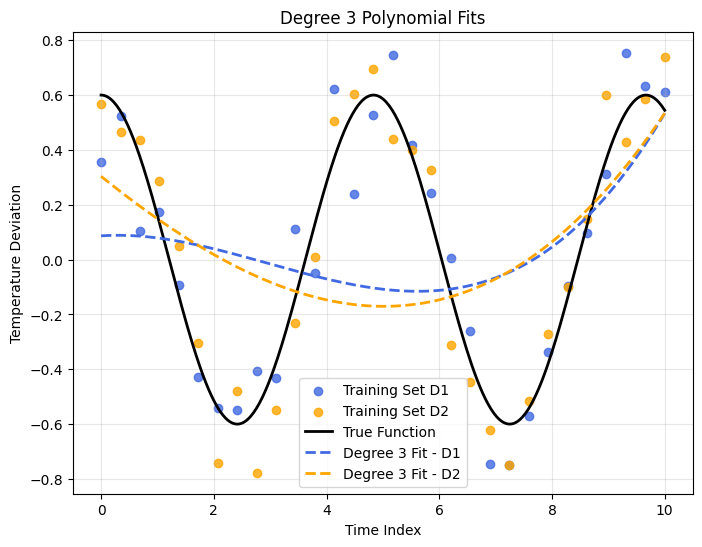

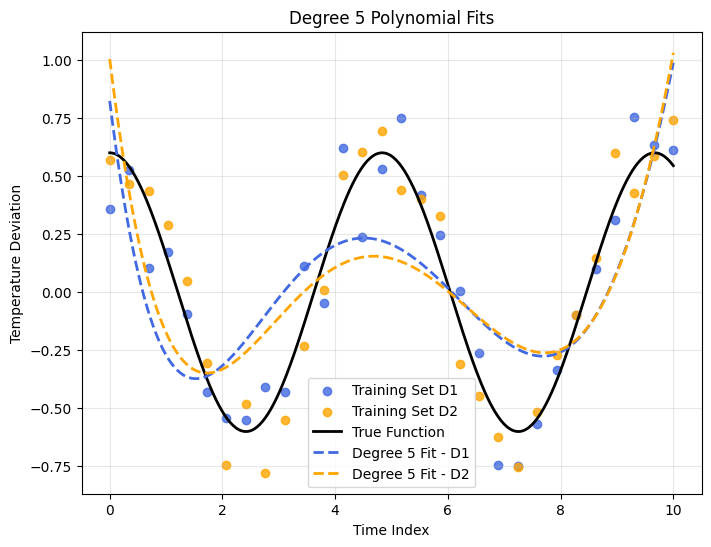

In [143]:
#we are producing the polynomial features for the input x up to the specified degree. np.vander creates a Vandermonde matrix, where each column corresponds to a power of x, starting from 0 (the bias term) up to the given degree. The increasing=True argument ensures that the powers are in increasing order, which is more intuitive for polynomial regression.
#f(x)=w0​+w1​x+w2​x2+⋯+wd​xd
#it increases the power
def build_poly_features(x, degree):
    return np.vander(x, N=degree + 1, increasing=True)

#we need to find weights
def fit_polynomial_regression(x, y, degree):
    X = build_poly_features(x, degree)
    w = np.linalg.solve(X.T @ X, X.T @ y)
    return w

#we are using the learned weights w to make predictions on new input x.
def predict_polynomial(x, w):
    degree = len(w) - 1
    X = build_poly_features(x, degree)
    return X @ w

#compute MSE
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

""" training """

w_d1_deg3 = fit_polynomial_regression(x_train_d1, y_train_d1, 3)
w_d2_deg3 = fit_polynomial_regression(x_train_d2, y_train_d2, 3)

y_test_pred_d1_deg3 = predict_polynomial(x_test, w_d1_deg3)
y_test_pred_d2_deg3 = predict_polynomial(x_test, w_d2_deg3)

#test mse
mse_d1_deg3 = compute_mse(y_test, y_test_pred_d1_deg3)
mse_d2_deg3 = compute_mse(y_test, y_test_pred_d2_deg3)


#deg 5
w_d1_deg5 = fit_polynomial_regression(x_train_d1, y_train_d1, 5)
w_d2_deg5 = fit_polynomial_regression(x_train_d2, y_train_d2, 5)

y_test_pred_d1_deg5 = predict_polynomial(x_test, w_d1_deg5)
y_test_pred_d2_deg5 = predict_polynomial(x_test, w_d2_deg5)

mse_d1_deg5 = compute_mse(y_test, y_test_pred_d1_deg5)
mse_d2_deg5 = compute_mse(y_test, y_test_pred_d2_deg5)

#results
print("Test MSE (degree 3, D1):", round(mse_d1_deg3, 4))
print("Test MSE (degree 3, D2):", round(mse_d2_deg3, 4))
print("Test MSE (degree 5, D1):", round(mse_d1_deg5, 4))
print("Test MSE (degree 5, D2):", round(mse_d2_deg5, 4))


x_plot = np.linspace(0, 10, 400)


y_plot_d1_deg3 = predict_polynomial(x_plot, w_d1_deg3)
y_plot_d2_deg3 = predict_polynomial(x_plot, w_d2_deg3)


y_plot_d1_deg5 = predict_polynomial(x_plot, w_d1_deg5)
y_plot_d2_deg5 = predict_polynomial(x_plot, w_d2_deg5)



plt.figure(figsize=(8, 6))


plt.scatter(x_train_d1, y_train_d1, color="royalblue", alpha=0.8, label="Training Set D1")
plt.scatter(x_train_d2, y_train_d2, color="orange", alpha=0.8, label="Training Set D2")


plt.plot(x_true, y_true, color="black", linewidth=2, label="True Function")


plt.plot(x_plot, y_plot_d1_deg3, color="royalblue", linestyle="--", linewidth=2, label="Degree 3 Fit - D1")
plt.plot(x_plot, y_plot_d2_deg3, color="orange", linestyle="--", linewidth=2, label="Degree 3 Fit - D2")

plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Degree 3 Polynomial Fits")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



plt.figure(figsize=(8, 6))


plt.scatter(x_train_d1, y_train_d1, color="royalblue", alpha=0.8, label="Training Set D1")
plt.scatter(x_train_d2, y_train_d2, color="orange", alpha=0.8, label="Training Set D2")


plt.plot(x_true, y_true, color="black", linewidth=2, label="True Function")


plt.plot(x_plot, y_plot_d1_deg5, color="royalblue", linestyle="--", linewidth=2, label="Degree 5 Fit - D1")
plt.plot(x_plot, y_plot_d2_deg5, color="orange", linestyle="--", linewidth=2, label="Degree 5 Fit - D2")

plt.xlabel("Time Index")
plt.ylabel("Temperature Deviation")
plt.title("Degree 5 Polynomial Fits")
plt.legend()
plt.grid(alpha=0.3)
plt.show()